# 🚢 Atividade 1 : Análise do Dataset De Baterias da Nasa

## 🎯 Objetivo do Estudo
Aplicar todas as técnicas aprendidas para analisar a relação de ciclos de carga e descarga de baterias Li-ion (íon lítio) e a aceleração
do processo de envelhecimento das baterias.

### 🔍 Perguntas que vamos responder:
1. **🔄 O primeiro ciclo de testes sempre é o que a bateria tem a maior capacidade?**
2. **🔋 A capacidade da bateria diminui ao longo dos ciclos de carga e descarga?**
3. **🌡️⚡A temperatura,  e tensão minima da bateria ao descarregar influemciam no processo de envelhecimento da bateria?**


### 📊 Sobre o Dataset:

O conjunto de dados que estamos utilizando é de um teste de envelhecimento acelerado conduzido pela NASA. Eles testaram 33 células de bateria diferentes, e cada uma delas passou por uma série de testes de ciclagem e de impedância
> **🎯 Meta:** Descobrir como a capacidade das baterias de íon lítio é afetada de a cordo com a quantidade de ciclos de carga e descarga!


1. **📥 Carregar** o dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

#Carregar os dados da Nasa
df_meta = pd.read_csv(r'C:\Users\paulo\Downloads\archive (1)\cleaned_dataset\metadata.csv')

df_meta.head(5)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


2. **🔍 Explorar** a estrutura dos dados

In [2]:

#O objetivo principal é validar se todos os 7.000+ arquivos de dados de bateria possuem a mesma estrutura de cabeçalho
#Como  foram vários testes diferentes, se houver cabeçalhos que não combinem, não será possível analisar tudo depois.


# Pegar todos os arquivos
files = list(df_meta["filename"])

#Deixar de fora os arquivos que não queremos
exclusion = ["metadata.csv", "charge.csv", "discharge.csv"]
files = [file for file in files if file not in exclusion]

#  Criar uma variável chamada path que guarda o texto do caminho  onde os 7.000 arquivos estão salvos.
path = 'C:\\Users\\paulo\\Downloads\\archive (1)\\cleaned_dataset\\data\\'
filepaths = [path + file for file in files]

# Função para conferir o cabeçalho dos arquivos
def get_header(filename):
    with open(filename, 'r') as file:
        csv_reader = csv.reader(file)
        header = next(csv_reader)
    return header

# Agora será usada compreensão de lista para pegar os cabeçalhos .

headers = [get_header(filepath) for filepath in filepaths]
headers

[['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_load',
  'Voltage_load',
  'Time'],
 ['Sense_current',
  'Battery_current',
  'Current_ratio',
  'Battery_impedance',
  'Rectified_Impedance'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_charge',
  'Voltage_charge',
  'Time'],
 ['Sense_current',
  'Battery_current',
  'Current_ratio',
  'Battery_impedance',
  'Rectified_Impedance'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_load',
  'Voltage_load',
  'Time'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_charge',
  'Voltage_charge',
  'Time'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_load',
  'Voltage_load',
  'Time'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',
  'Current_charge',
  'Voltage_charge',
  'Time'],
 ['Voltage_measured',
  'Current_measured',
  'Temperature_measured',


In [6]:
#Transforma a lista com os cabeçalhos em um dataframe
df_headers = pd.DataFrame(headers, columns=[ 'Coluna1','Coluna2','Coluna3','Coluna4','Coluna5','Coluna6'])
#Remove os valores repetidos
df_headers = df_headers.drop_duplicates()
df_headers

,Coluna1,Coluna2,Coluna3,Coluna4,Coluna5,Coluna6
0,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
1,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,None
2,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time


In [7]:
#Cria uma lista com os ids das baterias
cell_ids = list(set(df_meta["battery_id"]))
file_list = []
# Remove a  impedância (pois carga e dascarga já é o bastanta para a análise) 
# Armazena os nomes dos arquivos desejados em uma lista 

for cell_id in cell_ids:
    temp_list = list(df_meta[(df_meta["type"] !="impedance") & (df_meta["battery_id"] == cell_id)]["filename"])
    file_list.append( temp_list)
    
    
         
    

3. **🧹 Limpar** valores ausentes:

Este dataset possui alguns valores vazios referentes a capacidade das baterias. Será realizada a limpeza destes valores vazios\.
Para a limpeza dos valores vazios, será realizado o cálculo do valor da capacidade de cada bateria utilizando a fórmula da carga elétrica:
$$Q = \int_{t_{0}}^{t_{f}} i(t) \, dt$$\



In [8]:

#Muda o nome das colunas
def couloumb_count(df):
    new_column_names = ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                        'Current_load','Voltage_load', "Time" ]
    df.columns =  new_column_names
    voltage = df["Voltage_measured"]
    current = df["Current_measured"]
    time = df["Time"]
#Inicio do cálculo da capacidade de cada bateria    
    capacity_list=[]
    throughput = 0
    for i in range (len(voltage)):
        if i < len(voltage) -1:
            capacity = current[i]*(time[i+1] - time[i])/3600
            capacity_list.append(capacity)
            throughput += capacity
            
#Temperatura e corrente média
    avg_temp = np.mean(df["Temperature_measured"])
    avg_current = np.mean(df["Current_measured"])

    return(throughput, avg_temp, avg_current)
    
#A partir do filepath cria um dataframe usando Pandas
def df_reader(filepath):
    df = pd.read_csv(filepath)
    new_column_names = ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                        'Current_load','Voltage_load', "Time" ]
    df.columns = new_column_names
    throughput, avg_temp, avg_current = couloumb_count(df)
    output = [throughput, avg_temp, avg_current]
    return(output)

4. **🗂️ Preparar** para análise

In [9]:


path = 'C:\\Users\\paulo\\Downloads\\archive (1)\\cleaned_dataset\\data\\'

print(len(cell_ids))
print(len(file_list))

# Percorre todas as baterias e cada um de seus arquivos para calcular  a carga total  e as médias de temperatura e corrente de cada ciclo.
agg_cell_test_data = []

#Começa a percorrer cada bateria da lista
for i in range(len(cell_ids)):
    total_throughput = 0
    cell_test_data =[]
    #Entra na lista onde estão os nomes dos arquivos, e conta quantos arquivos cada bateria possui
    for j in range(len(file_list[i])):
        #Encontra o endereço do arquivo, lê o que tem dentro, e passa as informações para df_outputs
        df_outputs = df_reader(path +file_list[i][j])
        #Passa o valor do cálculo da capacitância para throughput
        throughput = df_outputs[0]
        total_throughput += abs(throughput)
        #Passa o valor do cálculo da temperatura média para  avg_temp
        avg_temp = df_outputs[1]
        #Passa o valor do cálculo da corrente média  para df_outputs
        avg_current = df_outputs[2]
        #Cria um dicionario com os valores, e coloca esse dicionario dentro da lista  cell_test_data
        cell_data = {"throughput": throughput, "avg_temp": avg_temp, "avg_current": avg_current, 
                     "cumulative_throughput": total_throughput}
        cell_test_data.append(cell_data)
        
       # Isso verifica se chegou no último arquivo.
        if j == len(file_list[i])-1:
            #Usa o cell_ids[i] para selecionar uma bateria com um id especifico
            #Mostra os valores utilizando o dicionario :cell_test_data de cada bateria especifica
            #Armazena esses valores na lista agg_cell_test_data
            agg_cell_test_data.append({cell_ids[i]:cell_test_data})
print("Aggregation complete")

34
34
Aggregation complete


In [10]:
agg_cell_test_data

[{'B0054': [{'throughput': np.float64(-0.8534834442360448),
    'avg_temp': np.float64(12.46348139823978),
    'avg_current': np.float64(-1.1710330967045812),
    'cumulative_throughput': np.float64(0.8534834442360448)},
   {'throughput': np.float64(1.555844162628417),
    'avg_temp': np.float64(6.4369727087359365),
    'avg_current': np.float64(0.538772481659788),
    'cumulative_throughput': np.float64(2.409327606864462)},
   {'throughput': np.float64(-1.2905086742730674),
    'avg_temp': np.float64(13.22908734445715),
    'avg_current': np.float64(-1.6489958041029575),
    'cumulative_throughput': np.float64(3.6998362811375296)},
   {'throughput': np.float64(1.3461559708716906),
    'avg_temp': np.float64(6.570424280835119),
    'avg_current': np.float64(0.46488347079688),
    'cumulative_throughput': np.float64(5.045992252009221)},
   {'throughput': np.float64(-1.2144050472544656),
    'avg_temp': np.float64(12.767949622305693),
    'avg_current': np.float64(-1.5571513787964162),
 

## 📊 b) Análise Exploratória com Gráficos

Vamos usar visualizações para responder nossas perguntas de pesquisa!

###  Pergunta 1: **🔄 O primeiro ciclo de testes sempre é o que a bateria tem a maior capacidade (throughput)?** 
> **Hipótese:** Como o primeiro valor de throughput representa a descarga da bateria, este valor sempre será menor do que ao carregar  a bateria, pois por conta de perdas internas da bateria, a energia que sai da bateria sempre será menor do que a energia que entra.


In [25]:
from IPython.display import display

# Transforma a estrutura em uma tabela plana
output_data = [{**{'Cell ID': key}, **value} for entry in agg_cell_test_data for key, 
                  values in entry.items() for value in values]
# Cria o DataFrame
output_df = pd.DataFrame(output_data)

#Adicionar ao dataframe a capacidade relativa da bateria, (capacidade atual/capacidade máxima) 
#Adicionar rastreador da carga total acumulada (total throughput) para plotar os dados em relação à 'idade' real de ciclos da célula da bateria.

#Vai pegar o DataFrame output_df, agrupar os dados pelo ID de cada bateria, olhar a parte de capacidade apenas e pegar o maior valor de cada capacidade
#Depois guarda em um dicionário
cell_max_throughputs = output_df.groupby("Cell ID")["throughput"].max().to_dict()
cell_max_throughputs

cap_ret = []
cap_list = []

#Percorre o dataframe output_df
#Pega o valor da coluna Cell_ID, de acordo com a sua posição e coloca o valor em cell
#Calcula a capacidade relativa
#Armazena o valor em cap_list
for i in range(len(output_df)):
    cell = output_df["Cell ID"][i]
    relative_capacity = abs(output_df["throughput"][i]) / cell_max_throughputs[cell]
    cap_list.append(relative_capacity)
output_df["Charge-approximated Capacity"] = cap_list
output_df=output_df.dropna()

#Display para a tabela 
print("📊 Estrutura dos Dados Processados:")
display(output_df)

print(f"\n🔍 Insights Técnicos (Análise de Corrente):")
# Explicação sobre o sinal da corrente/throughput
print(f"✓ Throughput Positivo: Representa a Carga (Energia entrando na bateria).")
print(f"✓ Throughput Negativo: Representa a Descarga (Energia saindo/trabalhando).")
print(f"✓ No cálculo de capacidade, usamos abs() para somar o fluxo total independente do sentido.")
print(f"✓  Os valores absolutos de descarga (throughput negativo)  são menores do que os de carga (throughput positivo)  .")


print(f"\n📋 Conclusões sobre a Tabela:")
print("✅ A estrutura foi 'achatada' para permitir análises estatísticas por célula.")
print("✅ Os valores nulos foram removidos para garantir a precisão dos cálculos de degradação.")
print("✅ A coluna 'Charge-approximated Capacity' permite perceber o quanto da capacidade atual da baterial em relação ao seu valor máximo de capacidade.")



📊 Estrutura dos Dados Processados:


,Cell ID,throughput,avg_temp,avg_current,cumulative_throughput,Charge-approximated Capacity
0,B0054,-0.853483,12.463481,-1.171033,0.853483,0.548566
1,B0054,1.555844,6.436973,0.538772,2.409328,1.000000
2,B0054,-1.290509,13.229087,-1.648996,3.699836,0.829459
3,B0054,1.346156,6.570424,0.464883,5.045992,0.865225
4,B0054,-1.214405,12.767950,-1.557151,6.260397,0.780544
...,...,...,...,...,...,...
5604,B0007,1.421408,25.431336,0.541790,554.418152,0.739092
5605,B0007,-1.445752,32.818049,-1.856101,555.863904,0.751750
5606,B0007,1.446901,25.138344,0.535054,557.310805,0.752347
5607,B0007,-1.456424,32.929412,-1.857437,558.767229,0.757299



🔍 Insights Técnicos (Análise de Corrente):
✓ Throughput Positivo: Representa a Carga (Energia entrando na bateria).
✓ Throughput Negativo: Representa a Descarga (Energia saindo/trabalhando).
✓ No cálculo de capacidade, usamos abs() para somar o fluxo total independente do sentido.
✓  Os valores absolutos de descarga (throughput negativo)  são menores do que os de carga (throughput positivo)  .

📋 Conclusões sobre a Tabela:
✅ A estrutura foi 'achatada' para permitir análises estatísticas por célula.
✅ Os valores nulos foram removidos para garantir a precisão dos cálculos de degradação.
✅ A coluna 'Charge-approximated Capacity' permite perceber o quanto da capacidade atual da baterial em relação ao seu valor máximo de capacidade.


###  **🔋 Pergunta 2: A capacidade da bateria diminui ao longo dos ciclos de carga e descarga?**
> **Hipótese:** Vários ciclos de carga e descarga aceleram o processo de eenvelhecimento da bateria


📊 Estrutura dos Dados Processados:


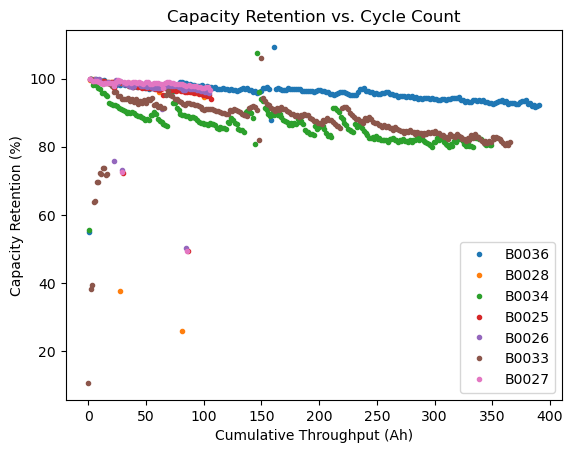


🔍 INSIGHTS TÉCNICOS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Degradação Linear: Observou-se uma queda de aproximadamente de 5%-20% na retenção de capacidade nominal das baterias ao longo do experimento.
✓ Efeito de Recuperação: Em intervalos de aproximadamente 50 ciclos, nota-se um incremento ('jump') de cerca de 5% na capacidade de retenção.

📋 CONCLUSÕES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Filtragem de Outliers: Identificamos inconsistências físicas (subidas drásticas > 5%) que devem ser desconsideradas, pois indicam ruídos de leitura  ou interrupções no teste.
✅ Variabilidade entre Células: Mesmo sob temperatura ambiente controlada (24°C), as baterias apresentaram taxas de degradação distintas, evidenciando a influência de variações de fabricação.
✅ Importância do Repouso : A subida  de aproximadamente 5% na capacidade após os ciclos de descarga mínima se da pelo das baterias terem sido submetidas há um descanso a c

In [27]:
#Vai pegar o csv dos dados do ambiente
#Vai fazer um left join de output_df com meta_df e a conexão  vai ser Cell Id
meta_df = pd.read_csv("meta_tags.csv")
merged_df = pd.merge(output_df, meta_df, on='Cell ID', how='left')

#Adiciona uma coluna de condição única, referente ao valores de temperatura ambiente, descarga e tensão mínima
#Os valores presentes em condição única são os que variam de a cordo com os experimentos 
merged_df["Unique_Condition"] = ("Temp: " 
                                 + merged_df["Ambient Temperature (deg C)"].astype(str)
                                 + "Discharge Profile"
                                 + merged_df["Discharge Profile "].astype(str)
                                 + "Min Voltage"
                                 + merged_df["Vmin"].astype(str))


#Exporta o dataframe para CSV para poder retoma-lo para futuras análises
merged_df.to_csv("Aggregated_Test_Data.csv")
merged_df = pd.read_csv("Aggregated_Test_Data.csv")
merged_df.sample(5)
#Para melhor entendimento do que está acontecendo, será realizado o plot de um gráfico de dispersão


#Pega  a series Cell Id do dataframe, tira as duplicatas, e coloca os valores em uma lista
#Percorre a lista, e para cada posição ele executa a função
#Ele olha para  o valor atual de i, e vê se é igual o valor do dataframe
#Depois faz um dataframe temporário apenas com os valores deste ID
#Esses outliers provevelmente indicam cargas parciais , e talvez em certos momentos o teste foi interrompido
#E podem não ser levados em consideração, por que a capacidade de uma bateria não iria de 80% para mais de 100% tão abrupta normalmente
def cell_plotter(df): 
    cells = list(set(df["Cell ID"]))
    for i in range(len(cells)): 
        temp_df = df[df["Cell ID"]==cells[i]]
        x = temp_df["cumulative_throughput"]
        y = temp_df["Charge-approximated Capacity"]*100
        plt.plot(x,y, '.',label=cells[i])
        #print(y.iloc[0])
        plt.legend()
        plt.title("Capacity Retention vs. Cycle Count")
        plt.xlabel("Cumulative Throughput (Ah)")
        plt.ylabel("Capacity Retention (%)")
        #plt.ylim(80,105)
plot_df = merged_df[merged_df["Ambient Temperature (deg C)"]=="24"]


print("📊 Estrutura dos Dados Processados:")
cell_plotter(plot_df)
plt.show()

print(f"\n🔍 INSIGHTS TÉCNICOS:")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✓ Degradação Linear: Observou-se uma queda de aproximadamente de 5%-20% na retenção de capacidade nominal das baterias ao longo do experimento.")
print(f"✓ Efeito de Recuperação: Em intervalos de aproximadamente 50 ciclos, nota-se um incremento ('jump') de cerca de 5% na capacidade de retenção.")


print(f"\n📋 CONCLUSÕES:")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print("✅ Filtragem de Outliers: Identificamos inconsistências físicas (subidas drásticas > 5%) que devem ser desconsideradas, pois indicam ruídos de leitura  ou interrupções no teste.")
print("✅ Variabilidade entre Células: Mesmo sob temperatura ambiente controlada (24°C), as baterias apresentaram taxas de degradação distintas, evidenciando a influência de variações de fabricação.")
print("✅ Importância do Repouso : A subida  de aproximadamente 5% na capacidade após os ciclos de descarga mínima se da pelo das baterias terem sido submetidas há um descanso a cada certa quantidade de ciclos,   demonstrando que o tempo de descanso permite a estabilização química interna, restaurando parcialmente a capacidade relativa.")


In [22]:
#Filtragem dos outliers


#Verifica se a proxima linha tem a mesma bateria que a linha anterior, para separar as condições
same_condition_mask = merged_df['Unique_Condition'] == merged_df['Unique_Condition'].shift()


#Olha a diferença de carga da mesma bateria entre cada ciclo
retention_diff = abs(merged_df['Charge-approximated Capacity'] - merged_df['Charge-approximated Capacity'].shift())


#Vai pegar o same condition mask e retention diff >0,05, ai vai mostrar a linha que isso acontece, e vai fazer uma lista
#com essas linhas
filtered_rows = merged_df.index[(same_condition_mask) & (retention_diff > 0.05)].tolist()

# Filtra as linhas em que ocorre uma mudança bruta de >5% na capacidade da bateria
merged_df = merged_df[~merged_df.index.isin(filtered_rows)]
merged_df.reset_index(drop=True)


,Unnamed: 0,Cell ID,throughput,avg_temp,avg_current,cumulative_throughput,Charge-approximated Capacity,Ambient Temperature (deg C),Charge profile (A),Discharge Profile,Vmax,Vmin,EIS Low (Hz),EIS High (Hz),Unique_Condition
0,0,B0054,-0.853483,12.463481,-1.171033,0.853483,0.548566,4,1.5,2A,4.2,2.2,0.1,5000,Temp: 4Discharge Profile2AMin Voltage2.2
1,18,B0054,-1.131340,12.449589,-1.528130,24.213519,0.727155,4,1.5,2A,4.2,2.2,0.1,5000,Temp: 4Discharge Profile2AMin Voltage2.2
2,19,B0054,1.129602,6.415956,0.390076,25.343121,0.726038,4,1.5,2A,4.2,2.2,0.1,5000,Temp: 4Discharge Profile2AMin Voltage2.2
3,28,B0054,-1.085948,11.961246,-1.497824,36.186580,0.697980,4,1.5,2A,4.2,2.2,0.1,5000,Temp: 4Discharge Profile2AMin Voltage2.2
4,29,B0054,1.085201,6.336509,0.372875,37.271781,0.697500,4,1.5,2A,4.2,2.2,0.1,5000,Temp: 4Discharge Profile2AMin Voltage2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4118,4507,B0007,-1.424460,32.576296,-1.835606,552.996744,0.740678,20,1.5,2A,4.2,2.2,0.1,5000,Temp: 20Discharge Profile2AMin Voltage2.2
4119,4508,B0007,1.421408,25.431336,0.541790,554.418152,0.739092,20,1.5,2A,4.2,2.2,0.1,5000,Temp: 20Discharge Profile2AMin Voltage2.2
4120,4509,B0007,-1.445752,32.818049,-1.856101,555.863904,0.751750,20,1.5,2A,4.2,2.2,0.1,5000,Temp: 20Discharge Profile2AMin Voltage2.2
4121,4510,B0007,1.446901,25.138344,0.535054,557.310805,0.752347,20,1.5,2A,4.2,2.2,0.1,5000,Temp: 20Discharge Profile2AMin Voltage2.2


### 🌡️  Pergunta 3. **A temperatura  e tensão minima da bateria ao descarregar influemciam no processo de envelhecimento da bateria?**
> **Hipótese 1 :** Temperatura ambiente pode interagir com as reações químicas internas da bateria, interferindo no seu processo de envelhecimento\.

> **Hipótese 2 :** A tensão o intervalo entre tensão minima e máxima ao carregar/descarregar podem talvez podem acelerar ou retardar o processso de envelhecimento da bateria.


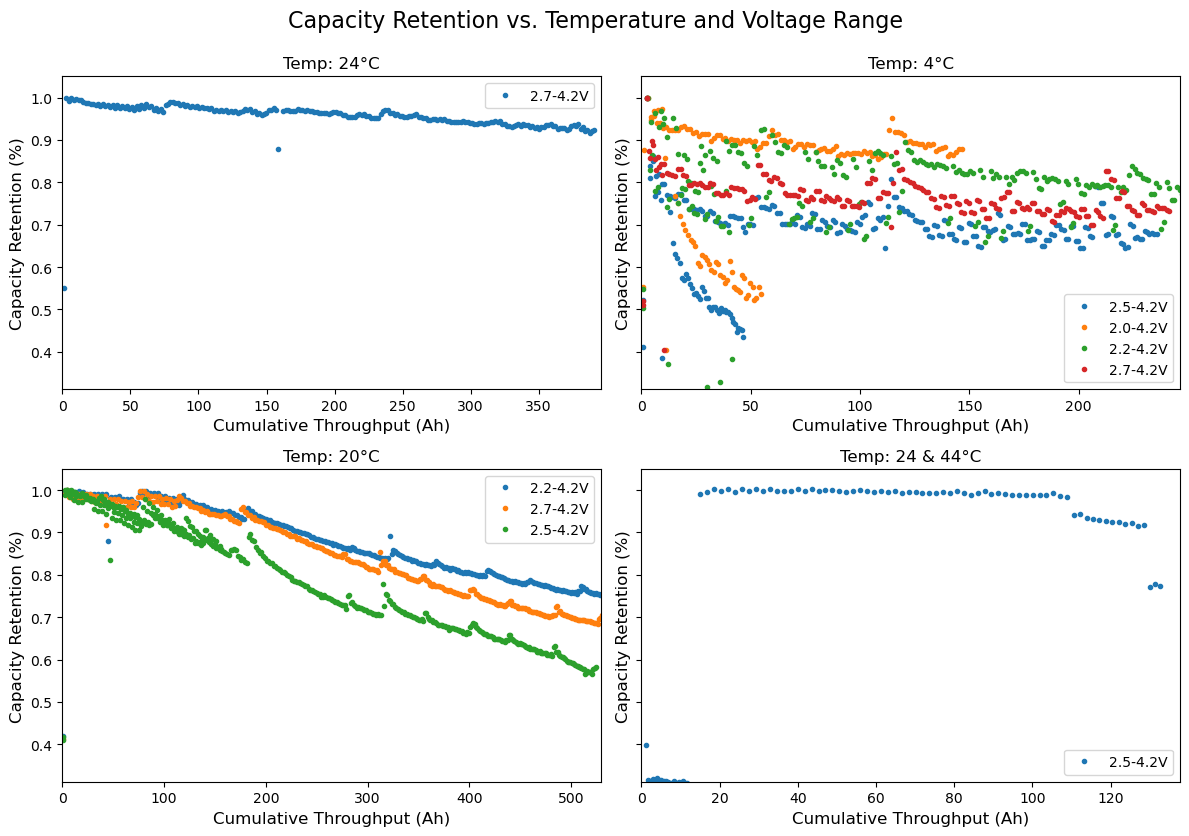


🔍 INSIGHTS TÉCNICOS (Janela de Operação 2.7V - 4.2V):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🌡️   A 24°C (Ambiente): Notou-se uma queda de capacidade de aproximadamente 10%.
❄️  A 4°C (Frio): A degradação acelerou, apresentando queda de aproximadamente 25%.
⚠️  A 20°C: Observou-se a queda mais acentuada, atingindo aproximadamente 30%.

⚡ INSIGHTS TÉCNICOS: TENSÃO MÍNIMA (Análise a 20°C)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Janela 2.5V - 4.2V: Observou-se a menor retenção final, de aprox. 60%.
✓ Janela 2.7V - 4.2V: Observou-se uma retenção intermediária de aprox. 70%.
✓ Janela 2.2V - 4.2V: Observou-se a maior retenção final, de aprox. 80%.

📋 CONCLUSÕES GERAIS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Otimização Térmica: A temperatura de 24°C foi a mais eficiente para a vida útil.
✅ Surpresa na Tensão: A tensão mínima de 2.2V apresentou a melhor retenção final, enquanto 2.5V teve o pior desemp

In [33]:
#### Plots de acordo com as condições do experimento, sendo que todos possuem a corrente de descarga fixa em 2A

#Filtra os dados com a descarga de 2A
subset_df = merged_df[(merged_df["Discharge Profile "] == "2A")]

#Cria lista de condição única e temperatura ambiente
unique_conditions = list(set(subset_df["Unique_Condition"]))
temps = list(set(subset_df["Ambient Temperature (deg C)"]))

#Prepara os espaços dos gráficos
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharey=True)

#Percorre a temperatura na lista temps
for idx, temp in enumerate(temps):
    row = idx // 2
    col = idx % 2

#Filtra os dados apenas para a temperatura da rodada atual
    temp_df = subset_df[subset_df["Ambient Temperature (deg C)"] == temp]
    temp_conditions = list(set(temp_df["Unique_Condition"]))
# Para cada temperatura, percorre as diferentes condições
    for condition in temp_conditions:
        condition_df = temp_df[temp_df["Unique_Condition"] == condition]
#Extrai os dados  para o plot        
        voltage = condition_df["Vmin"].iloc[0]
        capacity = condition_df["Charge-approximated Capacity"]
        throughput = condition_df["cumulative_throughput"]
        disch = condition_df["Discharge Profile "].iloc[0]
        axs[row, col].plot(throughput, capacity, '.', label="{}-4.2V".format(voltage)) # & temp {}°C

    axs[row, col].legend()

    # Set x and y axis limits
    axs[row, col].set_xlim([0, max(throughput)+5])  # Adjust the limits as needed
    axs[row, col].set_ylim([min(capacity)+0.05,1.05])     # Adjust the limits as needed
    axs[row, col].set_xlabel('Cumulative Throughput (Ah)',fontsize="12")  # Moved from plt.xlabel
    axs[row, col].set_ylabel('Capacity Retention (%)',fontsize="12")  # Moved from plt.ylabel
    axs[row, col].set_title("Temp: {}°C".format(temp),fontsize="12")  # Moved from plt.ylabel
plt.tight_layout()
fig.suptitle('Capacity Retention vs. Temperature and Voltage Range', fontsize=16, y=1.04 )

plt.show()

print(f"\n🔍 INSIGHTS TÉCNICOS (Janela de Operação 2.7V - 4.2V):")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"🌡️   A 24°C (Ambiente): Notou-se uma queda de capacidade de aproximadamente 10%.")
print(f"❄️  A 4°C (Frio): A degradação acelerou, apresentando queda de aproximadamente 25%.")
print(f"⚠️  A 20°C: Observou-se a queda mais acentuada, atingindo aproximadamente 30%.")

print(f"\n⚡ INSIGHTS TÉCNICOS: TENSÃO MÍNIMA (Análise a 20°C)")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✓ Janela 2.5V - 4.2V: Observou-se a menor retenção final, de aprox. 60%.")
print(f"✓ Janela 2.7V - 4.2V: Observou-se uma retenção intermediária de aprox. 70%.")
print(f"✓ Janela 2.2V - 4.2V: Observou-se a maior retenção final, de aprox. 80%.")

print(f"\n📋 CONCLUSÕES GERAIS:")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"✅ Otimização Térmica: A temperatura de 24°C foi a mais eficiente para a vida útil.")
print(f"✅ Surpresa na Tensão: A tensão mínima de 2.2V apresentou a melhor retenção final, enquanto 2.5V teve o pior desempenho.")
print(f"✅ Não-Linearidade: Assim como na temperatura, a relação entre os limites de tensão e a degradação não é linear.")